# Persona self-recognition — analysis

Walks through one run of the persona self-recognition experiment and produces the
plots and summary numbers used to evaluate it.

## The question

Take a single base model, induce it with several different persona system prompts
(chemist, five-year-old, artist, conservative, progressive), and have each persona
write a paragraph for the same prompts. Then ask each persona to identify which
texts are *its own*. **Does the model — under a given persona — recognize text
it produced under that same persona, more often than text from a different
persona?**

This is a behavioral skeleton only: high accuracy here is consistent with
self-recognition but does not establish privileged introspective access. The
results are diagnostic, not load-bearing.

## What gets logged

The experiment writes one `trials.jsonl` per run, with rows tagged by phase:

1. **Generation** — each persona writes one paragraph per prompt. These are the
   candidate texts re-used in the recognition phases.
2. **Individual recognition** — for every `(source, evaluator)` pair, the
   evaluator persona is shown one text and asked YES/NO: *did you write it?*
   Constrained probabilities over `{YES, NO}` are recorded.
3. **Paired recognition** — for every unordered pair of source personas and
   each task, the evaluator picks the candidate it would more likely have
   written. A/B order is counterbalanced. Ground truth exists only when the
   evaluator is itself one of the two source personas.

## What to look at, and what to mistrust

Two pitfalls are big enough to dominate naive readings of the matrices:

- **Answer-token bias.** A model that almost always says NO scores ≈ 0.80
  "individual accuracy" without doing any recognition (4/5 trials per source
  are ground-truth NO). A model with a strong A or B preference inflates one
  half of the paired matrix. Always cross-check the headline number against
  the answer-distribution cells before reading the matrices.
- **Length confound.** If one persona's outputs are much shorter than the
  others, recognition involving that persona is partly classifying length,
  not style. The five-year-old persona is the obvious offender here.

The right summary statistics, given those pitfalls:

- **Individual:** `diagonal_mean − off_diagonal_mean` (the diagonal advantage),
  in both argmax and P(YES) space. Overall accuracy is misleading on its own.
- **Paired:** overall accuracy, plus an accuracy recomputed with the length-
  outlier persona removed, plus the positional-bias breakdown.

Set `RUN_DIR` below and run-all. Math for each matrix is kept inline so it
can be inspected; figure styling lives in `analysis_helpers.py`.

In [1]:
RUN_DIR = "experiments/persona_self_recognition/results/self_recognition_SOURCE_POV_3_20260511_203859_484f1b"
# RUN_DIR = "experiments/persona_self_recognition/results/20260601_191757_3rd_dphn_Dolphin-Mistral-24B-Venice-Edition_self_recognition_misaligned"

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repo root importable when the notebook is run from anywhere.
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / "core").is_dir():
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core.results_logger import load_results
from experiments.persona_self_recognition.self_recognition_analysis_helpers import (
    plot_heatmap,
    plot_choice_bars,
)
from experiments.persona_self_recognition.self_recognition_experiment import (
    label_from_run_dir,
)

run_dir = (_REPO_ROOT / RUN_DIR).resolve()
df = load_results(run_dir / "trials.jsonl")

# Model label for figure annotations. Derived from the run-dir name, which
# encodes the short model slug (Llama_8b_base / _instruct / _<adapter> /
# Dolphin_Venice_24). Legacy dirs with no slug fall back to "Llama 3.1 8B
# Instruct". Every figure is tagged with this via the plt.show() wrapper below.
MODEL_LABEL = label_from_run_dir(run_dir.name)

# Stamp MODEL_LABEL onto every figure as a small footer, so each plot is
# self-identifying when exported. We wrap plt.show() once here so the figure
# cells below don't each need to repeat the annotation; the wrapper tags any
# open figure that hasn't been tagged yet (handles multi-figure cells too).
# Guard against double-wrapping when this cell is re-run.
if not getattr(plt.show, "_model_tagged", False):
    _orig_show = plt.show

    def _show_with_model_label(*args, **kwargs):
        for _num in plt.get_fignums():
            _fig = plt.figure(_num)
            if not getattr(_fig, "_model_label_added", False):
                _fig.text(
                    0.995, 0.005, f"model: {MODEL_LABEL}",
                    ha="right", va="bottom", fontsize=8,
                    color="0.4", style="italic",
                )
                _fig._model_label_added = True
        return _orig_show(*args, **kwargs)

    _show_with_model_label._model_tagged = True
    plt.show = _show_with_model_label

print(f"Loaded {len(df)} rows from {run_dir.name}")
print(f"model label: {MODEL_LABEL}")
df["phase"].value_counts()

Loaded 63000 rows from self_recognition_SOURCE_POV_3_20260511_203859_484f1b
model label: Llama 3.1 8B Instruct


phase
paired        60000
individual     2500
generation      500
Name: count, dtype: int64

## Source POV detection

Each run is either 1st-person (every persona writes as itself, the original
behavior) or 3rd-person (the chemist may be asked to "write as if you were a
five-year-old"). 3rd-person runs include a 1st-person diagonal alongside the
off-diagonal cross-pairings for direct comparison.

The cell below detects which mode this run used and constructs `df_1p`, the
1st-person subset (rows where `target_persona == source_persona` or where
the field is absent — i.e. legacy runs). All matrices in the sections that
follow are computed on `df_1p` so they stay 2D-interpretable. The off-diagonal
rows are unpacked in the **3rd-person analysis** section near the bottom of
the notebook.

In [3]:
SOURCE_POV = "1st_person"
if "source_pov" in df.columns:
    povs = df["source_pov"].dropna().unique().tolist()
    if "3rd_person" in povs:
        SOURCE_POV = "3rd_person"

# 1st-person subset: every row where the text was produced as the induced
# persona itself (target == source), plus legacy rows that pre-date the field.
if "target_persona" in df.columns:
    _tgt = df["target_persona"]
    df_1p = df[_tgt.isna() | (_tgt == df["source_persona"])].copy()
else:
    df_1p = df.copy()

print(f"SOURCE_POV:       {SOURCE_POV}")
print(f"all rows:         {len(df)}")
print(f"1st-person rows:  {len(df_1p)}")
if SOURCE_POV == "3rd_person":
    print()
    print("Matrices below use only the 1st-person diagonal (target == source).")
    print("Off-diagonal rows are unpacked in the '3rd-person analysis' section.")

SOURCE_POV:       3rd_person
all rows:         63000
1st-person rows:  60600

Matrices below use only the 1st-person diagonal (target == source).
Off-diagonal rows are unpacked in the '3rd-person analysis' section.


### Inspect raw trials with d-tale
Opens a local d-tale browser tab on the full DataFrame for filtering / column inspection.
Re-running this cell reuses the same instance. `pip install dtale` if needed.

In [4]:
import dtale
import dtale.global_state as _dtale_gs

# d-tale gotchas this cell handles:
#   1. `name` rejects special chars — letters, numbers, spaces only.
#   2. Re-running `dtale.show()` with the same name returns None (silent fail).
#      We free the slot with `cleanup(data_id)` first so re-runs always work
#      and pick up the latest `df`.
#   3. `host="localhost"` makes the URL forwardable through Cursor/VSCode SSH.
#      Without it, d-tale embeds the container hostname (e.g. Runpod's Docker
#      ID) which can't resolve from your local browser.
DTALE_NAME = "self recognition"

_existing_id = _dtale_gs.get_data_id_by_name(DTALE_NAME)
if _existing_id is not None:
    _dtale_gs.cleanup(_existing_id)

dtale_instance = dtale.show(
    df, name=DTALE_NAME, host="localhost", open_browser=True,
)
print(f"d-tale URL: {dtale_instance.main_url()}")
dtale_instance

http://localhost:40000/dtale/main/self_recognition
d-tale URL: None


## Run config
Header of `manifest.txt` — model, personas, sampling, prompt template knobs.


In [5]:
manifest = (run_dir / "manifest.txt").read_text()
# Show everything up through the prompt templates; skip the per-phase example dumps.
header_end = manifest.find("EXAMPLE TRIALS")
print(manifest[:header_end] if header_end != -1 else manifest)

PERSONA SELF-RECOGNITION — RUN MANIFEST
run_id:     20260511_203859_484f1b
started_at: 2026-05-11T20:40:16.239605+00:00
model:      meta-llama/Llama-3.1-8B-Instruct

CONFIG (from config.yaml + RunConfig)
------------------------------------------------------------
  personas: ['chemist', 'five_year_old', 'artist', 'conservative', 'progressive']
  task_sets: ['self_recognition']
  sample_size: None
  seed: 42
  max_new_tokens: 160
  temperature: 0.0
  output_dir: experiments/persona_self_recognition/results
  strip_self_refs: True
  n_manifest_examples: 3
  source_pov: 3rd_person

PERSONA SYSTEM PROMPTS
------------------------------------------------------------
[chemist]
You are an AI assistant with deep expertise in chemistry. You have extensive knowledge of organic chemistry, inorganic chemistry, biochemistry, and physical chemistry. You approach questions from a chemist's perspective and are especially confident in chemistry-related topics.

[five_year_old]
You are a 5-year-old chi

## Phase 1 — Generation

Sanity check: did every persona produce text for every prompt, and roughly how
long? With 5 personas × 20 tasks we expect 100 generations and zero errors.

The mean and spread of `token_length` per persona are the most important
numbers on this page — they are also the **length confound** for the
recognition phases. If one persona's paragraphs are systematically shorter
or longer than the others, an evaluator can identify them on length alone,
which inflates "recognition accuracy" without any persona-style signal being
involved. Watch the per-persona `mean` and `min/max` ranges below; the
boxplot underneath visualizes the same data.

In [6]:
gen = df_1p[df_1p["phase"] == "generation"]
n_errors = int(gen["error"].notna().sum())
print(f"generation trials: {len(gen)}    errors: {n_errors}")
gen.groupby("source_persona")["token_length"].agg(["count", "mean", "std", "min", "max"])

generation trials: 100    errors: 0


,count,mean,std,min,max
source_persona,,,,,
artist,20,128.55,11.509607,108.0,153.0
chemist,20,119.25,8.005755,106.0,133.0
conservative,20,118.25,10.813612,94.0,137.0
five_year_old,20,46.55,7.755982,34.0,63.0
progressive,20,122.60,15.855930,97.0,155.0


In [ ]:
# Token-length distribution per persona. Clear separation between rows is a
# length cue available to the recognition phases for free — read: confound.
fig, ax = plt.subplots(figsize=(8, 3.5))
gen.boxplot(column="token_length", by="source_persona", ax=ax, grid=False)
ax.set_title("Generated text length by persona")
ax.set_xlabel("source persona")
ax.set_ylabel("tokens")
plt.suptitle("")  # boxplot adds an outer title; clear it
plt.show()

# Text mirror of the boxplot so the figure is readable without the image.
print("Token-length distribution by persona (tokens):")
print(
    gen.groupby("source_persona")["token_length"]
       .describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
       .round(1).to_string()
)

## Phase 2a — Individual recognition

The evaluator persona is shown one paragraph at a time and asked YES/NO:
*did you write this?* The model returns constrained probabilities over
`{YES, NO}`; argmax gives the parsed choice. We compute one cell per
`(source, evaluator)` combination, averaging `is_correct` across tasks.

### How to read the matrix

|             | columns = `evaluator_persona` (who is being asked) |
|-------------|----------------------------------------------------|
| **rows**    | `source_persona` (who actually wrote the text)     |
| **diagonal** (`source == evaluator`) | ground-truth answer is YES — accuracy here is the rate at which the evaluator correctly claims its own text |
| **off-diagonal**                     | ground-truth answer is NO — accuracy here is the rate at which the evaluator correctly denies someone else's text |

A model that recognizes itself should put the **diagonal above the
off-diagonal**. The single number that captures this is the
**diagonal advantage = diagonal_mean − off_diagonal_mean**, computed
two cells down. That is the headline number for self-recognition,
**not** overall accuracy.

### Why "overall accuracy" misleads here

Each row has 1 ground-truth-YES cell and 4 ground-truth-NO cells. A model
that always says NO scores ≈ 0.80 overall accuracy and produces a matrix
that *looks* like it has structure (high off-diagonal, low diagonal) but
contains no recognition signal at all. A negative diagonal advantage is the
diagnostic for this: it means the model is *more* confident denying its
own text than denying others' — NO-bias has overwhelmed any self-signal.

To rule that in or out, two cells follow:
1. The diagonal vs off-diagonal split (the calibrated headline number).
2. The YES/NO answer distribution per evaluator (does the model actually
   use both tokens?).

In [8]:
ind = df_1p[(df_1p["phase"] == "individual") & df_1p["error"].isna()].copy()

ind_matrix = ind.pivot_table(
    index="source_persona",
    columns="evaluator_persona",
    values="is_correct",
    aggfunc="mean",
)
ind_matrix

evaluator_persona,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,0.65,1.0,1.0,1.0,1.0
chemist,0.95,0.45,1.0,1.0,1.0
conservative,0.95,1.0,0.35,1.0,1.0
five_year_old,1.0,1.0,1.0,1.0,1.0
progressive,1.0,1.0,1.0,1.0,0.35


In [ ]:
plot_heatmap(ind_matrix, title="Individual recognition accuracy")
plt.show()
# Text mirror of the heatmap (rows = source/author, cols = evaluator).
print("Individual recognition accuracy — mean is_correct (rows=source, cols=evaluator):")
print(ind_matrix.round(3).to_string())

In [10]:
# Diagonal vs off-diagonal — the headline number for self-recognition.
common = [p for p in ind_matrix.index if p in ind_matrix.columns]
diag_vals, off_vals = [], []
for s in common:
    for e in common:
        v = ind_matrix.loc[s, e]
        if pd.isna(v):
            continue
        (diag_vals if s == e else off_vals).append(float(v))

diag_mean = float(np.mean(diag_vals)) if diag_vals else float("nan")
off_mean = float(np.mean(off_vals)) if off_vals else float("nan")

print(f"diagonal mean (source == evaluator): {diag_mean:.3f}")
print(f"off-diagonal mean:                   {off_mean:.3f}")
print(f"diagonal advantage:                  {diag_mean - off_mean:+.3f}")
print(f"overall accuracy:                    {ind['is_correct'].mean():.3f}")

diagonal mean (source == evaluator): 0.560
off-diagonal mean:                   0.995
diagonal advantage:                  -0.435
overall accuracy:                    0.908


### Answer distribution per evaluator

The matrix above is only as trustworthy as the model's willingness to use
both YES and NO. If an evaluator answers NO on essentially every trial,
its row of the matrix collapses to a base-rate artifact: the off-diagonal
will look great (the answer is NO four times out of five) and the diagonal
will look terrible, but neither cell reflects recognition.

What to look for: bars that are radically uneven for a given evaluator.
Those are the evaluators whose row of the accuracy matrix you cannot
interpret as self-recognition without re-reading via the calibrated
P(YES) heatmap below.

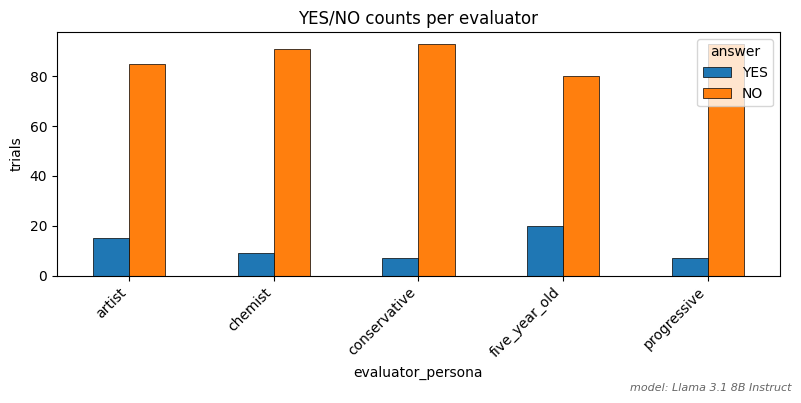

answer,YES,NO
evaluator_persona,,
artist,15,85
chemist,9,91
conservative,7,93
five_year_old,20,80
progressive,7,93


In [11]:
ind_choice_counts = (
    ind.groupby(["evaluator_persona", "parsed_choice"]).size()
       .unstack(fill_value=0)
       .reindex(columns=["YES", "NO"], fill_value=0)
)
ind_choice_counts.columns.name = "answer"
plot_choice_bars(ind_choice_counts, title="YES/NO counts per evaluator", ylabel="trials")
plt.show()
ind_choice_counts

### P(YES) — beyond argmax

Argmax accuracy collapses calibration: a `(YES=0.49, NO=0.51)` trial scores
zero just like `(YES=0.01, NO=0.99)`. Mean YES probability shows whether
the model is *leaning* the right way even when the wrong token wins by a
hair — it's the more sensitive instrument for self-recognition, and it's
much less sensitive to a generic NO-bias.

Read this heatmap the same way as the accuracy matrix: rows = source,
columns = evaluator. The diagonal should be **brighter** than the
off-diagonal. The numeric diagonal advantage in P(YES) space is reported
underneath; compare it to the argmax diagonal advantage from the cell
above to see how much of the apparent "no recognition" is calibration vs
a real flat signal.

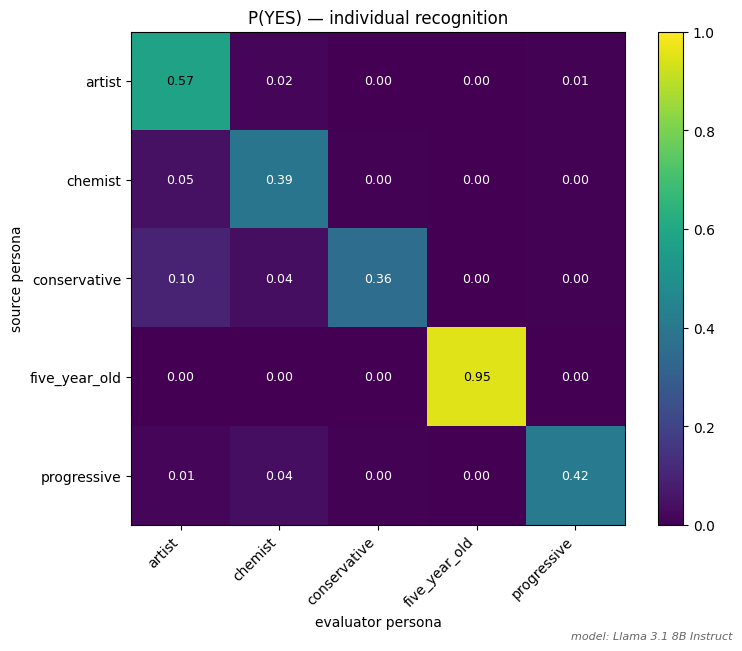

P(YES) diagonal mean (own text):     0.537
P(YES) off-diagonal mean (others'):  0.014
P(YES) diagonal advantage:           +0.523


evaluator_persona,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,0.574782,0.018797,0.002171,0.000014,0.005445
chemist,0.045690,0.389010,0.004832,0.000009,0.004718
conservative,0.099725,0.038116,0.355704,0.000018,0.004486
five_year_old,0.000326,0.000054,0.000403,0.949357,0.000323
progressive,0.014318,0.038364,0.004871,0.000021,0.416943


In [12]:
ind["p_yes"] = ind["choice_probs"].apply(
    lambda d: d.get("YES") if isinstance(d, dict) else np.nan
)
yes_matrix = ind.pivot_table(
    index="source_persona",
    columns="evaluator_persona",
    values="p_yes",
    aggfunc="mean",
)
plot_heatmap(yes_matrix, title="P(YES) — individual recognition")
plt.show()

# Diagonal vs off-diagonal in P(YES) space — the calibrated counterpart
# to the argmax diagonal advantage. Same interpretation: positive means
# the model is more YES-leaning on its own text than on others'.
common_p = [p for p in yes_matrix.index if p in yes_matrix.columns]
diag_p_vals, off_p_vals = [], []
for s in common_p:
    for e in common_p:
        v = yes_matrix.loc[s, e]
        if pd.isna(v):
            continue
        (diag_p_vals if s == e else off_p_vals).append(float(v))
diag_p_mean = float(np.mean(diag_p_vals)) if diag_p_vals else float("nan")
off_p_mean = float(np.mean(off_p_vals)) if off_p_vals else float("nan")
print(f"P(YES) diagonal mean (own text):     {diag_p_mean:.3f}")
print(f"P(YES) off-diagonal mean (others'):  {off_p_mean:.3f}")
print(f"P(YES) diagonal advantage:           {diag_p_mean - off_p_mean:+.3f}")
yes_matrix

### Signal detection: criterion-free recognition (d′)

Both `P(YES)` and argmax accuracy mix two distinct things: *how well the model
separates its own text from others'* (sensitivity) and *how willing it is to say
YES at all* (criterion). The strong NO-bias in the answer-distribution bars is a
**criterion** shift — it drags the diagonal (hits) and the off-diagonal (false
alarms) down *together*. So a low diagonal P(YES) like 0.39 is **not** evidence
of poor recognition by itself; it only means something read against the
false-alarm rate.

The bias-free summary is **d′ = z(hit) − z(false-alarm)**, which subtracts the
criterion out:

- `hit = P(YES | own text)` — the diagonal, where YES is the correct answer.
- `false-alarm = P(YES | others' text)` — the off-diagonal, where NO is correct.

d′ = 0 means no discrimination no matter how YES- or NO-happy the model is;
larger is better. `hit − FA` is the same idea on the raw-rate scale. Rates are
clamped off {0, 1} so the z-transform stays finite, which caps the maximum
resolvable d′. Compare this to the diagonal advantage above: the diagonal
advantage can go negative purely from a NO-bias, while a positive d′ confirms
real separation underneath it.

In [ ]:
from scipy.stats import norm

# d' separates *sensitivity* (can it tell own text from others'?) from
# *criterion* (the NO-bias). SDT inputs are response RATES, so we use the
# argmax YES-rate, not the calibrated p_yes; hit - FA in p_yes space is the
# calibrated companion (already computed above as diag_p_mean - off_p_mean).
ind["claims_authorship"] = (ind["parsed_choice"] == "YES").astype(float)

LO, HI = 0.025, 0.975  # clamp so z(0)/z(1) stay finite; this caps resolvable d'
_z = lambda p: float(norm.ppf(min(max(float(p), LO), HI)))

_is_self = ind["source_persona"] == ind["evaluator_persona"]
hit = float(ind.loc[_is_self, "claims_authorship"].mean())   # YES is correct
fa = float(ind.loc[~_is_self, "claims_authorship"].mean())   # NO is correct

print("Signal detection — individual recognition (1st-person diagonal)")
print(f"  hit rate     P(YES | own text)   : {hit:.3f}")
print(f"  false-alarm  P(YES | others')    : {fa:.3f}")
print(f"  hit - FA (argmax rate)           : {hit - fa:+.3f}")
print(f"  hit - FA (calibrated p_yes)      : {diag_p_mean - off_p_mean:+.3f}")
print(f"  d' = z(hit) - z(FA)              : {_z(hit) - _z(fa):+.3f}   (0 = no discrimination)")
print()

# Per-evaluator: a NO-happy evaluator can still post a healthy d' as long as its
# hits stay above its false alarms. This is the criterion-free row read.
rows = []
for e in sorted(ind["evaluator_persona"].dropna().unique()):
    sub = ind[ind["evaluator_persona"] == e]
    s = sub["source_persona"] == e
    h = float(sub.loc[s, "claims_authorship"].mean())
    f = float(sub.loc[~s, "claims_authorship"].mean())
    rows.append({"evaluator": e, "hit": h, "FA": f, "hit - FA": h - f, "d'": _z(h) - _z(f)})
sdt_ind = pd.DataFrame(rows).set_index("evaluator")
print("Per-evaluator signal detection (argmax YES-rate):")
print(sdt_ind.round(3).to_string())

plot_choice_bars(
    sdt_ind[["hit", "FA"]],
    title="Individual recognition: hit vs false-alarm rate by evaluator",
    ylabel="P(YES)", ylim=(0.0, 1.0),
)
plt.show()

## Phase 2b — Paired recognition

The evaluator is shown two paragraphs side-by-side and picks the one it
"would more likely have written." Every unordered pair runs once as `ab`
(`A=s1, B=s2`) and once as `ba` (`A=s2, B=s1`), so position cancels out
across counterbalanced trials.

Ground truth exists only when the evaluator is itself one of the two
authors — the other trials (e.g. asking the chemist persona to compare
artist vs. progressive) have no "right" answer and are filtered out for
this matrix. They come back into play in the bias diagnostics below.

### How to read the matrix

The matrix below is best read as:

> *"When persona X (row) sees its own text alongside persona Y's (column)
>  on the same prompt, what fraction of the time does it pick its own?"*

Concretely:

- **Rows (`source_persona`)** — the evaluator. Filtered so the evaluator
  is one of the two authors, so this is also "self".
- **Columns (`partner`)** — the *other* persona in the pair. This is who
  self is being contrasted against.
- **Cell value** — mean `is_correct` across all tasks and both `ab` and
  `ba` orderings, where "correct" means picking the candidate written by
  self.

So `paired_matrix.loc["chemist", "artist"] = 0.925` reads:
*"when the chemist persona is shown its own text alongside an artist's
text on the same prompt, it picks its own text 92.5% of the time,
averaged across tasks and A/B order."*

### Caveats baked into the matrix

- The matrix is **asymmetric**. `[chemist, artist]` and `[artist, chemist]`
  are different experiments — different evaluator, different system prompt
  active when the choice is made. Don't assume symmetry.
- The diagonal is **NaN**: a persona is never paired against itself, so
  there's no `(self, self)` cell to fill.
- Any row or column involving a persona with very different output length
  (here, `five_year_old`) reflects length classification more than style
  recognition. A length-controlled accuracy is computed below the heatmap.
- High accuracy can coexist with strong positional bias — counterbalancing
  hides the bias from the matrix, but it shows up in the bias diagnostics
  further down. A separate cell splits accuracy by where the own-text
  actually sat (A vs B) to confirm bias isn't doing the work.

### Chance baseline

Random guessing gives 0.5 per cell. Anything well above that — say > 0.7 —
is real signal of *something* (style, length, formatting, lexical choice).
Whether that "something" is recognition vs surface features is what the
follow-up controls are for.

In [13]:
paired = df_1p[
    (df_1p["phase"] == "paired")
    & df_1p["error"].isna()
    & (df_1p["has_ground_truth"] == True)
].copy()

# `source_persona` is set to the evaluator on ground-truth trials; partner = the other.
paired["partner"] = paired.apply(
    lambda r: r["candidate_b_source"]
    if r["candidate_a_source"] == r["source_persona"]
    else r["candidate_a_source"],
    axis=1,
)
paired_matrix = paired.pivot_table(
    index="source_persona",
    columns="partner",
    values="is_correct",
    aggfunc="mean",
)
paired_matrix

partner,artist,chemist,conservative,five_year_old,progressive
source_persona,,,,,
artist,NaN,0.538,0.481,0.788,0.468
chemist,0.511,NaN,0.441,0.768,0.412
conservative,0.53,0.516,NaN,0.631,0.499
five_year_old,0.68,0.664,0.67,NaN,0.664
progressive,0.527,0.539,0.527,0.67,NaN


In [ ]:
plot_heatmap(
    paired_matrix,
    title="Paired recognition accuracy (own vs partner)",
    xlabel="partner persona",
    ylabel="self (evaluator)",
)
plt.show()
print(f"overall paired accuracy: {paired['is_correct'].mean():.3f}")
print()
# Text mirror of the heatmap (rows = self/evaluator, cols = partner; NaN diagonal).
print("Paired accuracy — P(picks own text) (rows=self/evaluator, cols=partner):")
print(paired_matrix.round(3).to_string())

### Length-controlled accuracy

The headline paired accuracy is partly inflated by the length signature of
the `five_year_old` persona — its outputs are roughly half the token count
of the others, and any pair that involves it is closer to a length
classification task than a style recognition task.

The honest measure of style recognition is paired accuracy with the length
outlier removed. The cell below recomputes it on the subset of trials where
neither candidate was authored by the length outlier.

In [15]:
length_outlier = "five_year_old"

paired_balanced = paired[
    (paired["source_persona"] != length_outlier)
    & (paired["partner"] != length_outlier)
]

print(f"paired accuracy (all):                          {paired['is_correct'].mean():.3f}")
print(f"paired accuracy (excluding {length_outlier!r}): {paired_balanced['is_correct'].mean():.3f}")
print(f"  trials kept: {len(paired_balanced)} / {len(paired)}")

paired accuracy (all):                          0.576
paired accuracy (excluding 'five_year_old'): 0.499
  trials kept: 12000 / 20000


### Answer distribution per evaluator

A vs B counts per evaluator across **all** paired trials, including the
no-ground-truth ones (where the evaluator wasn't one of the authors).
With every pair counterbalanced, a content-driven evaluator should land
near 50/50 — same content, just relabeled — so a strong tilt toward A or
B reveals a fixed positional preference.

Some positional bias is normal in instruction-tuned models. A large bias
muddies the recognition story because the "correct" answer can coincide
with the preferred slot. The next cell quantifies how much.

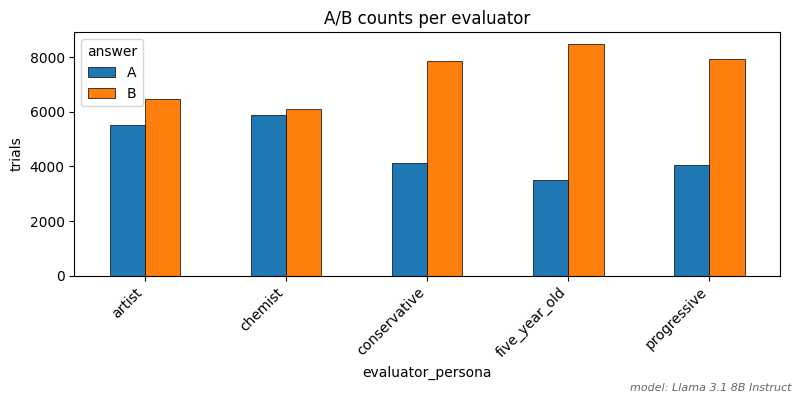

answer,A,B
evaluator_persona,,
artist,5516,6484
chemist,5900,6100
conservative,4123,7877
five_year_old,3503,8497
progressive,4070,7930


In [16]:
paired_all = df_1p[(df_1p["phase"] == "paired") & df_1p["error"].isna()].copy()
paired_all["chose_A"] = (paired_all["parsed_choice"] == "A").astype(float)

paired_choice_counts = (
    paired_all.groupby(["evaluator_persona", "parsed_choice"]).size()
              .unstack(fill_value=0)
              .reindex(columns=["A", "B"], fill_value=0)
)
paired_choice_counts.columns.name = "answer"
plot_choice_bars(paired_choice_counts, title="A/B counts per evaluator", ylabel="trials")
plt.show()
paired_choice_counts

### Positional bias by display order

Each unordered pair runs twice: once as `(A=s1, B=s2)` (`order=ab`) and
once swapped to `(A=s2, B=s1)` (`order=ba`). For a content-driven
evaluator the two orderings should land on opposite sides of 0.5 for a
given pair — high `P(A | ab)` ↔ low `P(A | ba)`. If both sit on the same
side, the model has a fixed positional preference that survives swapping
the contents.

Three signals to read:

1. **Overall P(choose A)** — should be near 0.5. A value far from 0.5
   means the model has a global A or B preference applied irrespective
   of content.
2. **P(A) split by display order** — `ab` and `ba` should be on opposite
   sides of 0.5 (since swapping contents swaps which slot the "preferred"
   text is in). If both are below 0.5, the model has B-preference
   regardless of contents.
3. **Accuracy by display order** — should be similar across `ab` and
   `ba`. A large gap means the bias eats into recognition asymmetrically:
   the model is much better when the right answer happens to sit in its
   preferred slot.

Counterbalancing absorbs symmetric bias when computing aggregate
accuracy, so a moderate bias can coexist with high accuracy in the
matrix above. The follow-up cell breaks accuracy down by where the
*ground-truth* own-text actually sat (A vs B), which is the cleanest
test of whether positional bias is doing the work.

In [17]:
p_choose_a = paired_all["chose_A"].mean()
print(f"overall P(choose A): {p_choose_a:.3f}    (0.5 = no bias)")
print()
print("P(choose A) by display order (averaged over evaluators and pairs):")
print(paired_all.groupby("pair_order")["chose_A"].mean().round(3))
print()
print("Accuracy by display order (ground-truth trials only):")
print(paired.groupby("pair_order")["is_correct"].mean().astype(float).round(3))

overall P(choose A): 0.385    (0.5 = no bias)

P(choose A) by display order (averaged over evaluators and pairs):
pair_order
ab    0.344
ba    0.426
Name: chose_A, dtype: float64

Accuracy by display order (ground-truth trials only):
pair_order
ab    0.611
ba    0.541
Name: is_correct, dtype: float64


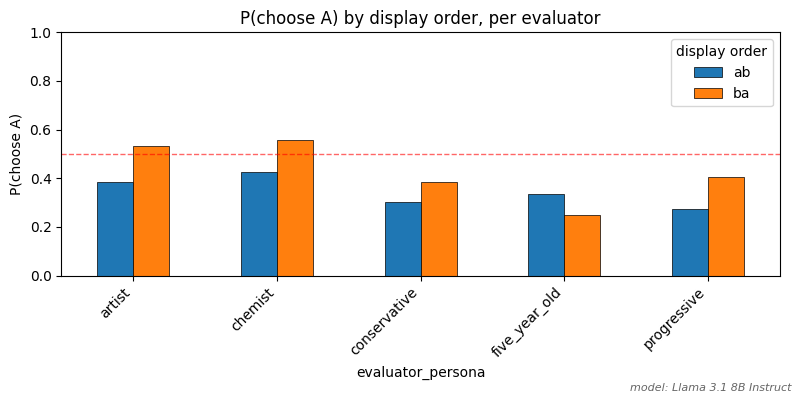

display order,ab,ba
evaluator_persona,,
artist,0.385,0.534
chemist,0.427,0.557
conservative,0.302,0.385
five_year_old,0.334,0.250
progressive,0.272,0.406


In [18]:
# Per-evaluator P(choose A) split by display order. Red dashed line = unbiased baseline.
bias_pivot = (
    paired_all.groupby(["evaluator_persona", "pair_order"])["chose_A"]
              .mean()
              .unstack()
)
bias_pivot.columns.name = "display order"
plot_choice_bars(
    bias_pivot,
    title="P(choose A) by display order, per evaluator",
    ylabel="P(choose A)",
    ylim=(0.0, 1.0),
    hline=0.5,
)
plt.show()
bias_pivot.round(3)

### Accuracy by ground-truth position

The cleanest test of whether positional bias is masquerading as recognition.
For each ground-truth trial we record which slot (A or B) actually contained
the evaluator's own text. If recognition is real, accuracy should hold up
roughly equally whether own-text was at A or at B. If positional bias is
doing the work, accuracy will be much higher when own-text happens to sit
in the model's preferred slot.

Because the experiment counterbalances order, both buckets should have
the same trial count (~half each).

In [19]:
paired = paired.copy()
paired["own_letter"] = paired.apply(
    lambda r: "A" if r["candidate_a_source"] == r["source_persona"] else "B",
    axis=1,
)

print("Accuracy by ground-truth position of own text:")
print(paired.groupby("own_letter")["is_correct"].mean().astype(float).round(3))
print()
print("Trial counts:")
print(paired.groupby("own_letter").size())

Accuracy by ground-truth position of own text:
own_letter
A    0.476
B    0.677
Name: is_correct, dtype: float64

Trial counts:
own_letter
A    10000
B    10000
dtype: int64


## Summary

Headline numbers for this run, with the calibration caveats baked in. The
two metrics that actually answer the research question are the **diagonal
advantages** (individual phase) and the **length-controlled paired
accuracy**. Overall accuracy and P(choose A) are kept alongside as
sanity checks, not as conclusions.

In [20]:
print(f"run:    {run_dir.name}")
print(f"model:  {df['model'].iloc[0]}")
print(f"tasks:  {df['task_id'].nunique()}")
print(f"personas: {sorted(df['source_persona'].dropna().unique().tolist())}")
print()
print("INDIVIDUAL RECOGNITION  (diagonal advantage = own-text accuracy − others'-text accuracy)")
print(f"  diagonal advantage (argmax):              {diag_mean - off_mean:+.3f}")
print(f"  diagonal advantage (P(YES), calibrated):  {diag_p_mean - off_p_mean:+.3f}")
print(f"  overall accuracy:                         {ind['is_correct'].mean():.3f}   "
      f"(can be inflated by NO-bias — see distribution above)")
print()
print("PAIRED RECOGNITION")
print(f"  overall accuracy:                         {paired['is_correct'].mean():.3f}")
print(f"  accuracy excluding {length_outlier!r}:        "
      f"{paired_balanced['is_correct'].mean():.3f}   (length-controlled)")
print(f"  P(choose A):                              {p_choose_a:.3f}   "
      f"(0.5 = no positional bias)")

run:    self_recognition_SOURCE_POV_3_20260511_203859_484f1b
model:  meta-llama/Llama-3.1-8B-Instruct
tasks:  20
personas: ['artist', 'chemist', 'conservative', 'five_year_old', 'progressive']

INDIVIDUAL RECOGNITION  (diagonal advantage = own-text accuracy − others'-text accuracy)
  diagonal advantage (argmax):              -0.435
  diagonal advantage (P(YES), calibrated):  +0.523
  overall accuracy:                         0.908   (can be inflated by NO-bias — see distribution above)

PAIRED RECOGNITION
  overall accuracy:                         0.576
  accuracy excluding 'five_year_old':        0.499   (length-controlled)
  P(choose A):                              0.385   (0.5 = no positional bias)


---

## Response-format bias analysis

These cells separate genuine self-recognition from **response-format bias** — a
global YES/NO lean, an A/B position preference, or mis-calibrated
self-probabilities. They read the optional-mode columns the experiment writes
(`individual_probability`, `paired_confidence`, `yes_no_logprobs`) and are
**backward compatible**: on a run that did not enable a mode, the matching cell
reports "no data" instead of failing, and legacy files missing the columns load
fine (missing columns are filled with NaN).

All logic lives in `self_recognition_bias_analysis.py`; the cells below are thin
wrappers, and every figure is tagged with the model label by the `plt.show()`
wrapper set up at the top of the notebook.

In [ ]:
import experiments.persona_self_recognition.self_recognition_bias_analysis as bias

# One-call headline across whichever modes this run produced. Sections for modes
# that were not enabled are simply omitted (backward compatible with old runs).
import json as _json
print(_json.dumps(bias.bias_summary(df), indent=2, default=str))

### Individual YES/NO — response-bias diagnostics

A `yes_rate` near 0 or 1 for an evaluator means it barely uses both tokens, so
its individual-recognition accuracy is a base-rate artifact rather than
recognition. When the run recorded logprobs (`yes_no_logprobs: true`), the
`logprob_yes - logprob_no` margin compares the model's *graded* YES-lean on its
own text vs others' — a calibration-sensitive signal that survives argmax ties.

In [ ]:
yes_rate_tbl = bias.yes_rate_by_evaluator(df, by_model=True)
print("YES rate by evaluator (and model) — response-bias diagnostic:")
display(yes_rate_tbl.round(3))
bias.plot_yes_rate_by_evaluator(df)
plt.show()

logprob_margin_tbl = bias.yes_logprob_margin_by_self(df)
if logprob_margin_tbl.empty:
    print("\nNo YES/NO logprobs recorded for this run (yes_no_logprobs was off).")
else:
    print("\nlogprob_yes - logprob_no by self/nonself:")
    display(logprob_margin_tbl.round(3))
    bias.plot_yes_logprob_margin(df)
    plt.show()

### Individual probability (0-100)

The numeric self-probability mode. Self-vs-nonself score distributions and
**AUROC** measure whether the stated probability separates own text from
others' (0.5 = chance, higher = better). **Calibration** compares the stated
probability to the empirical self-rate per bin. Parse-failure rate is reported
first — a high rate means the score columns are sparse and the metrics fragile.

In [ ]:
prob_fail = bias.probability_parse_failure_rate(df)
print(f"individual_probability parse-failure rate: "
      f"{prob_fail['parse_failure_rate']:.3f} "
      f"({prob_fail['n_parse_failures']}/{prob_fail['n_trials']})")

mean_prob_tbl = bias.mean_probability_by_evaluator(df)
if mean_prob_tbl.empty:
    print("No individual_probability data for this run (mode was off).")
else:
    display(mean_prob_tbl.round(2))
    bias.plot_probability_distributions(df)
    plt.show()
    bias.plot_mean_probability_by_evaluator(df)
    plt.show()

In [ ]:
if mean_prob_tbl.empty:
    print("No individual_probability data — skipping AUROC / calibration.")
else:
    print(f"AUROC (self vs nonself, overall): {bias.auroc_self_vs_nonself(df):.3f}")
    print("\nAUROC by evaluator (NaN where too few samples per class):")
    display(bias.auroc_by_evaluator(df).round(3))
    print("\nCalibration (predicted self-prob vs empirical self-rate):")
    display(bias.calibration_table(df, bins=10))
    bias.plot_calibration(df, bins=10)
    plt.show()

### Paired (A/B) — counterbalanced bias

`accuracy_chose_self` is recognition accuracy (P it picks its own text).
`p_choose_a` away from 0.5 is a fixed position preference; comparing
`accuracy_self_at_A` vs `accuracy_self_at_B` shows whether that preference is
doing the work (a large gap = bias masquerading as recognition). Confidence, if
recorded, is split by whether the model actually picked its own text.

In [ ]:
import json as _json
paired_bias = bias.paired_summary(df)
print(_json.dumps(paired_bias, indent=2, default=str))
bias.plot_paired_accuracy_by_evaluator(df)
plt.show()
bias.plot_position_bias_by_evaluator(df)
plt.show()

In [ ]:
conf_fail = bias.paired_confidence_parse_failure_rate(df)
conf_tbl = bias.confidence_correct_vs_incorrect(df)
if conf_tbl.empty:
    print("No paired confidence recorded for this run (paired_confidence was off).")
else:
    print(f"confidence parse-failure rate: {conf_fail['parse_failure_rate']:.3f} "
          f"({conf_fail['n_parse_failures']}/{conf_fail['n_trials']})")
    print("\nMean confidence — chose self vs chose other:")
    display(conf_tbl.round(2))
    print("\nMean confidence by evaluator:")
    display(bias.mean_confidence_by_evaluator(df).round(2))
    bias.plot_confidence_correct_vs_incorrect(df)
    plt.show()

---

## 3rd-person analysis

The sections above use only `target == source` rows so the matrices stay 2D.
When `SOURCE_POV == "3rd_person"`, the model also wrote in *other* personas'
voices while system-prompted as itself — those rows live in the
off-diagonal and need a different framing to be readable.

The cells below are no-ops on a 1st-person run. On a 3rd-person run they
unpack three things:

1. **Generation length by (induced × target).** Does length track the
   inducing persona's habits, or the target persona's style?
2. **Individual recognition buckets.** For each generation, we asked every
   evaluator persona "did you write this?" Sorting the (evaluator, induced,
   target) cube into four buckets makes the style-vs-author question
   readable directly: how often does each bucket claim authorship?
3. **Per-evaluator bucket heatmap.** Same buckets, broken out by evaluator.

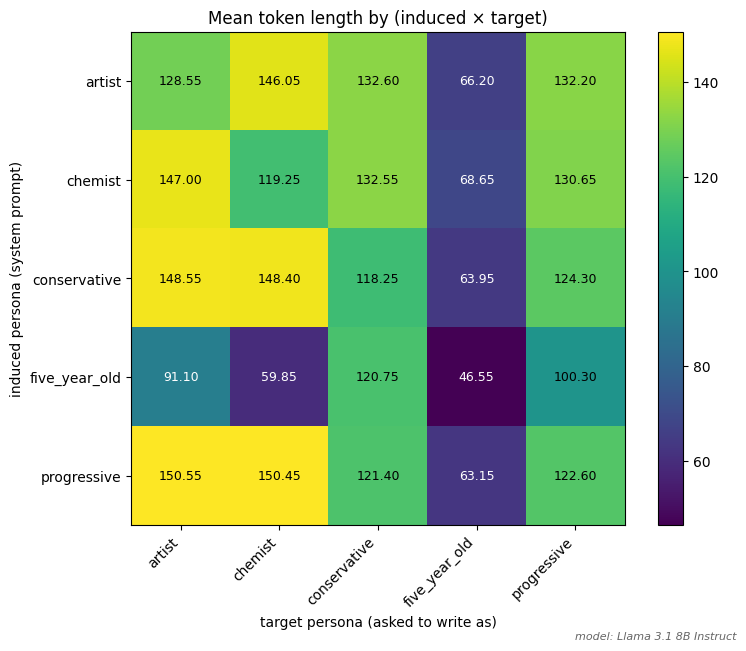

In [21]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping 3rd-person analysis cells.")
else:
    gen3 = df[df["phase"] == "generation"].copy()
    length_pivot = gen3.pivot_table(
        index="source_persona",
        columns="target_persona",
        values="token_length",
        aggfunc="mean",
    )
    vmin, vmax = float(length_pivot.min().min()), float(length_pivot.max().max())
    plot_heatmap(
        length_pivot,
        title="Mean token length by (induced × target)",
        xlabel="target persona (asked to write as)",
        ylabel="induced persona (system prompt)",
        vmin=vmin, vmax=vmax,
    )
    plt.show()
    length_pivot.round(1)

### Individual recognition — author vs style buckets

For each (induced, target) generation and each evaluator, the trial falls
into one of four buckets:

| bucket             | evaluator vs (induced, target)              | reading                                                                  |
|--------------------|---------------------------------------------|--------------------------------------------------------------------------|
| **author + style** | evaluator == induced == target              | 1st-person self-recognition baseline (same data as the matrices above)   |
| **author only**    | evaluator == induced ≠ target               | the model is shown text it really wrote, but in someone else's voice     |
| **style only**     | evaluator == target ≠ induced               | the model is shown text in its own style, but written by another persona |
| **neither**        | evaluator ≠ induced and evaluator ≠ target  | unrelated control — false-positive baseline                              |

If recognition is purely stylistic, *style only* tracks *author + style*.
If recognition tracks the model's hidden state at authoring time, *author
only* should beat *style only*. *neither* is the false-positive floor —
both *author only* and *style only* should sit clearly above it.

`p_yes` is the calibrated number; `claims_authorship` is the argmax rate.
The two diverge when the model is hedging on a token boundary; treat
P(YES) as the headline.

In [22]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    ind3 = df[(df["phase"] == "individual") & df["error"].isna()].copy()
    ind3["p_yes"] = ind3["choice_probs"].apply(
        lambda d: d.get("YES") if isinstance(d, dict) else np.nan
    )
    ind3["claims_authorship"] = (ind3["parsed_choice"] == "YES").astype(float)

    def _bucket(r):
        eva, ind_, tgt = r["evaluator_persona"], r["source_persona"], r["target_persona"]
        author = eva == ind_
        style = eva == tgt
        if author and style:
            return "author + style"
        if author:
            return "author only"
        if style:
            return "style only"
        return "neither"

    ind3["bucket"] = ind3.apply(_bucket, axis=1)

    bucket_order = ["author + style", "author only", "style only", "neither"]
    summary_buckets = (
        ind3.groupby("bucket")[["p_yes", "claims_authorship"]]
            .agg(["mean", "count"])
            .reindex(bucket_order)
    )
    print("Mean P(YES) and argmax claim rate by recognition bucket:")
    summary_buckets.round(3)

Mean P(YES) and argmax claim rate by recognition bucket:


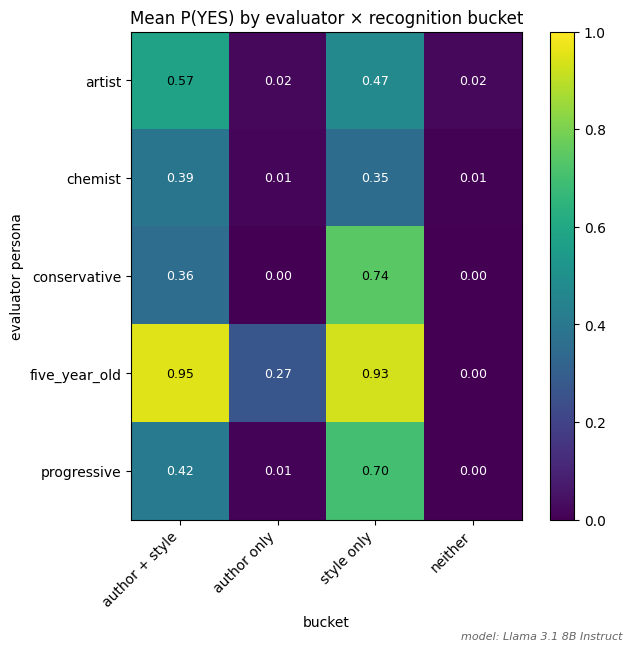

In [23]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    eval_bucket_matrix = ind3.pivot_table(
        index="evaluator_persona",
        columns="bucket",
        values="p_yes",
        aggfunc="mean",
    ).reindex(columns=bucket_order)
    plot_heatmap(
        eval_bucket_matrix,
        title="Mean P(YES) by evaluator × recognition bucket",
        xlabel="bucket",
        ylabel="evaluator persona",
    )
    plt.show()
    eval_bucket_matrix.round(3)

### Signal detection by bucket — is it self-recognition or style?

This is the criterion-free read of the four buckets, and it answers "is a P(YES)
of 0.39 actually good given the NO-bias?" directly. Ground truth per bucket:

- **author + style** → YES is correct → these are **hits**.
- **neither** → NO is correct → these are **false alarms** (the floor).
- **author only** / **style only** → the diagnostic pair: which cue is the model
  actually using?

`d′ = z(hit) − z(FA)` subtracts the NO-bias out, so it measures separation only.
The cue dissociation underneath shows P(YES) lift above the *neither* floor per
bucket: if **style only ≫ author only**, the model is recognizing its own
*style*, not its own *authorship* — i.e. the diagonal P(YES) is style matching
surviving a conservative criterion, not introspective self-recognition. A 0.39
hit rate against a ~0.02 false-alarm floor is a real, large d′ (the separation is
genuine); it is simply *not* 39% "accuracy", and the source of that separation is
what the author-only-vs-style-only split adjudicates.

In [ ]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — see the 1st-person d′ cell above.")
else:
    from scipy.stats import norm

    LO, HI = 0.025, 0.975
    _z = lambda p: float(norm.ppf(min(max(float(p), LO), HI)))

    # Pooled SDT. Ground truth per bucket: author+style -> YES correct (hits),
    # neither -> NO correct (false alarms). Use argmax YES-rate as the response
    # rate; p_yes lift is the calibrated companion.
    bmean = ind3.groupby("bucket")[["claims_authorship", "p_yes"]].mean()
    hit = float(bmean.loc["author + style", "claims_authorship"])
    fa = float(bmean.loc["neither", "claims_authorship"])
    print("Signal detection by bucket (pooled over evaluators)")
    print(f"  hit rate    P(YES | author+style) : {hit:.3f}")
    print(f"  false-alarm P(YES | neither)      : {fa:.3f}")
    print(f"  hit - FA (argmax rate)            : {hit - fa:+.3f}")
    print(f"  d' = z(hit) - z(FA)               : {_z(hit) - _z(fa):+.3f}   (0 = no discrimination)")
    print()

    # Cue dissociation: which signal is the model actually using? Lift over the
    # 'neither' false-positive floor, in calibrated p_yes.
    floor = float(bmean.loc["neither", "p_yes"])
    print("Cue dissociation — P(YES) lift above the 'neither' floor:")
    for b in ["author + style", "author only", "style only"]:
        print(f"  {b:<15} : p_yes={bmean.loc[b, 'p_yes']:.3f}   lift={bmean.loc[b, 'p_yes'] - floor:+.3f}")
    print("  style only >> author only  =>  recognition tracks STYLE, not authorship")
    print()

    # Per-evaluator d' (hit = author+style, FA = neither).
    claim_matrix = ind3.pivot_table(
        index="evaluator_persona", columns="bucket",
        values="claims_authorship", aggfunc="mean",
    ).reindex(columns=bucket_order)
    sdt = pd.DataFrame({
        "hit (author+style)": claim_matrix["author + style"],
        "FA (neither)": claim_matrix["neither"],
    })
    sdt["hit - FA"] = sdt["hit (author+style)"] - sdt["FA (neither)"]
    sdt["d'"] = [_z(h) - _z(f) for h, f in zip(sdt["hit (author+style)"], sdt["FA (neither)"])]
    print("Per-evaluator signal detection (argmax YES-rate):")
    print(sdt.round(3).to_string())

    plot_choice_bars(
        sdt[["hit (author+style)", "FA (neither)"]],
        title="Bucket SDT: hit (author+style) vs false-alarm (neither) by evaluator",
        ylabel="P(YES)", ylim=(0.0, 1.0),
    )
    plt.show()

### Per-bucket P(YES) — evaluator × author

The four buckets above collapse each (evaluator, induced, target) trial down
to a single category. The next plot unpacks them back out: one 5×5 heatmap
per bucket, with rows = evaluator persona and columns = author persona
(`source_persona`, i.e. the induced persona that actually generated the text).
Cell value = mean P(YES) over all trials with that (evaluator, author)
combination that fall into the bucket.

A given bucket only populates a subset of the 5×5 grid because the bucket
condition constrains how `evaluator` relates to `author` (and to the target
style):

- **author + style** — `eval == author == target`: only the diagonal has data
  (trials where author == eval and the text was *also* written in eval's own
  style). This is the 1st-person self-recognition baseline.
- **author only** — `eval == author ≠ target`: also diagonal-only, but
  drawn from trials where the model wrote in someone *else's* voice. Compare
  to *author + style* — if recognition needs the style match, this drops.
- **style only** — `eval == target ≠ author`: off-diagonal only. The text is
  in eval's style but was written by another persona. Compare to *neither*
  — if style is the cue, this is higher.
- **neither** — `eval ≠ author and eval ≠ target`: off-diagonal only. The
  false-positive floor.

Empty cells (NaN) are shown blank — they aren't reachable given the bucket
definition.

In [ ]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    personas = sorted(
        set(ind3["evaluator_persona"].dropna().unique())
        | set(ind3["source_persona"].dropna().unique())
    )

    fig, axes = plt.subplots(2, 2, figsize=(2 * (1.4 * len(personas) + 2),
                                            2 * (1.0 * len(personas) + 1.5)))
    for ax, bucket_name in zip(axes.flat, bucket_order):
        sub = ind3[ind3["bucket"] == bucket_name]
        mat = (
            sub.pivot_table(
                index="evaluator_persona",
                columns="source_persona",
                values="p_yes",
                aggfunc="mean",
            )
            .reindex(index=personas, columns=personas)
        )
        plot_heatmap(
            mat,
            title=f"P(YES) — {bucket_name}",
            xlabel="author persona (source_persona)",
            ylabel="evaluator persona",
            ax=ax,
        )
    fig.tight_layout()
    plt.show()

    # Text mirror: print each bucket's evaluator × author P(YES) matrix so the
    # four heatmaps are readable without the image. Blank cells are NaN —
    # unreachable given the bucket's evaluator/author/target constraint.
    for bucket_name in bucket_order:
        sub = ind3[ind3["bucket"] == bucket_name]
        mat = (
            sub.pivot_table(
                index="evaluator_persona", columns="source_persona",
                values="p_yes", aggfunc="mean",
            ).reindex(index=personas, columns=personas)
        )
        print(f"\nP(YES) — {bucket_name}  (rows=evaluator, cols=author/source):")
        print(mat.round(3).to_string())

### Per-bucket P(YES) — source × style (evaluator implied by bucket)

Same 4-bucket split, but plotted on a fixed pair of *generation* axes:

- **rows (y)** = `source_persona` (the system-prompt persona — who actually generated the text)
- **columns (x)** = `target_persona` (the persona the model was asked to write *as*)

Every (source, target) cell exists, so the 5×5 grids are reachable in
principle. What changes per bucket is **which evaluator's answer is read
out** in each cell:

- **author + style:** evaluator = source = target → only the diagonal is populated (1 trial/cell)
- **author only:** evaluator = source (= row) → only off-diagonal is populated (1 trial/cell — text was authored by row-persona, in column-persona's voice; row-persona judges)
- **style only:** evaluator = target (= column) → only off-diagonal is populated (1 trial/cell — text was authored by row-persona; column-persona judges because it's in their style)
- **neither:** evaluator ≠ source and evaluator ≠ target → every cell populated, averaged over the 3 (off-diag) or 4 (diag) eligible evaluators

So the evaluator changes from bucket to bucket; it's no longer pinned to the row.

In [ ]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(2 * (1.4 * len(personas) + 2),
                                            2 * (1.0 * len(personas) + 1.5)))
    for ax, bucket_name in zip(axes.flat, bucket_order):
        sub = ind3[ind3["bucket"] == bucket_name]
        mat = (
            sub.pivot_table(
                index="source_persona",
                columns="target_persona",
                values="p_yes",
                aggfunc="mean",
            )
            .reindex(index=personas, columns=personas)
        )
        plot_heatmap(
            mat,
            title=f"P(YES) — {bucket_name}",
            xlabel="written in the style of (target_persona)",
            ylabel="system prompt persona (source_persona)",
            ax=ax,
        )
    fig.tight_layout()
    plt.show()

    # Text mirror of the four source × target heatmaps.
    for bucket_name in bucket_order:
        sub = ind3[ind3["bucket"] == bucket_name]
        mat = (
            sub.pivot_table(
                index="source_persona", columns="target_persona",
                values="p_yes", aggfunc="mean",
            ).reindex(index=personas, columns=personas)
        )
        print(f"\nP(YES) — {bucket_name}  (rows=source/author, cols=target/style):")
        print(mat.round(3).to_string())

### Per-prompt cell values across all four buckets

Same data as the four heatmaps, but un-aggregated over prompts: one row per
`task_id` (= distinct prompt the model saw), and one column per cell of one
plot. 25 (evaluator, author) combos × 4 buckets = 100 columns, in a
MultiIndex `(bucket, evaluator_persona, source_persona)`.

Cells unreachable for a given bucket (e.g. `bucket = "author only"` with
`eval ≠ author`) stay NaN. For `author only` and `neither`, the value is the
mean of `p_yes` across the targets that fall into that bucket on that prompt
(4 trials each); for `author + style` and `style only` it's a single trial.

In [26]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    per_prompt_buckets = (
        ind3.groupby(["task_id", "bucket", "evaluator_persona", "source_persona"])["p_yes"]
            .mean()
            .unstack(["bucket", "evaluator_persona", "source_persona"])
    )
    # Force all 100 columns (4 buckets × 5 evaluators × 5 authors), even where unreachable.
    all_cols = pd.MultiIndex.from_tuples(
        [(b, e, a) for b in bucket_order for e in personas for a in personas],
        names=["bucket", "evaluator_persona", "source_persona"],
    )
    bucket_table = per_prompt_buckets.reindex(columns=all_cols)
    print(f"shape: {bucket_table.shape}    (rows = prompts, cols = (bucket, evaluator, author))")
    bucket_table

shape: (20, 100)    (rows = prompts, cols = (bucket, evaluator, author))


In [27]:
if SOURCE_POV != "3rd_person":
    print("1st_person run — skipping.")
else:
    # d-tale doesn't render MultiIndex columns gracefully — flatten the column
    # names and promote task_id to a regular column so it's filterable.
    flat = bucket_table.copy()
    flat.columns = [f"{b} | eval={e} | author={a}" for (b, e, a) in flat.columns]
    flat = flat.reset_index()

    DTALE_BUCKET_NAME = "bucket table"
    _existing = _dtale_gs.get_data_id_by_name(DTALE_BUCKET_NAME)
    if _existing is not None:
        _dtale_gs.cleanup(_existing)

    bucket_dtale = dtale.show(
        flat, name=DTALE_BUCKET_NAME, host="localhost", open_browser=True,
    )
    print(f"d-tale URL: {bucket_dtale.main_url()}")
    bucket_dtale

http://localhost:40000/dtale/main/bucket_table
d-tale URL: None
